Filename : _1_model.ipynb <br>
Title : Intrusion Detection Prediction - Modelling <br>
Author : raghav | GitHub : @raghavtwenty <br>
Date Created : June 10, 2023 | Last Updated : June 20, 2023 <br>
Language : Python | Version : 3.11.3, 64-bit <br>

## Importing Required Libraries

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as mpl
import joblib
import pandas as pd

## Confusion Matrix function for plotting

In [62]:
def displayConfusMatrix(actual, pred):
    confusMatrix = confusion_matrix(actual, pred)
    confusMatrixDis = ConfusionMatrixDisplay(confusion_matrix=confusMatrix, display_labels=[
        "Normal",
        "Blackhole",
        "TCP-SYN",
        "PortScan",
        "Diversion"])
    confusMatrixDis.plot()
    mpl.show()


## Load the dataset

In [63]:
location = pd.read_csv("../dataset/ids_dataset_updated.csv")

dataFrame = pd.DataFrame(location)

## View the dataset

In [64]:
dataFrame

,Port Number,Received Packets,Received Bytes,Sent Bytes,Sent Packets,Port alive Duration (S),Delta Port alive Duration (S),Connection Point,Packets Looked Up,Packets Matched,Label
0,4,305111,25506841,100234870,284579,1657,5,4,992868,992744,0
1,2,209,20671,6316631,274,96,5,2,90551,90494,3
2,4,150,19774,6475473,3054,166,5,4,7516,7418,2
3,1,4699,100986365,124574097,413351,2267,5,1,664849,664714,0
4,3,990,104058,88896,778,792,5,4,4328,4201,1
...,...,...,...,...,...,...,...,...,...,...,...
4922,3,180657,158912655,195046297,291446,2597,5,3,669087,668951,0
4923,1,180388,51777654,12692793,299993,1700,5,2,957168,957036,0
4924,2,3051,31735692,140143,1046,1496,5,2,7902,7772,1
4925,3,183279,209436883,101192774,156080,2890,5,3,667137,667002,0


## Selecting predictor variables and the target variable

In [65]:
predictors = dataFrame.iloc[:,:-1]  # Leave the last column alone
target = dataFrame.iloc[:,-1]   # Select the last column alone

## Split the data for training and testing

In [66]:
# 80 train : 20 test
predTrain, predTest, tarTrain, tarTest = train_test_split(
                                                                predictors,
                                                                target,
                                                                train_size=0.8,
                                                                test_size=0.2,
                                                                shuffle=True)

## KNN 

In [67]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(predTrain, tarTrain)
KNNTestResult = knn.predict(predTest)
KNNAccuracyScore = accuracy_score(tarTest, KNNTestResult)
print(f"Accuracy of the KNN Model : {KNNAccuracyScore:.2f}")

Accuracy of the KNN Model : 0.76


## Confusion matrix for the KNN Model

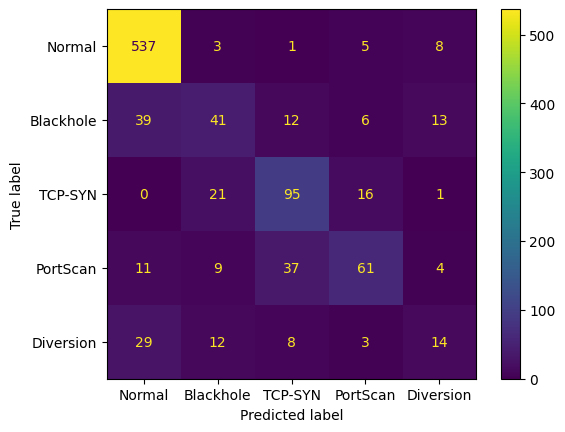

In [68]:
displayConfusMatrix(tarTest, KNNTestResult)

## Naive Bayes

In [69]:
naiveBayes = GaussianNB()
naiveBayes.fit(predTrain, tarTrain)
NBTestResult = naiveBayes.predict(predTest)
NBAccuracyScore = accuracy_score(tarTest, NBTestResult)
print(f"Accuracy of the Naive Bias Gaussian Model : {NBAccuracyScore:.2f}")

Accuracy of the Naive Bias Gaussian Model : 0.82


## Confusion matrix for the Naive Bayes Model

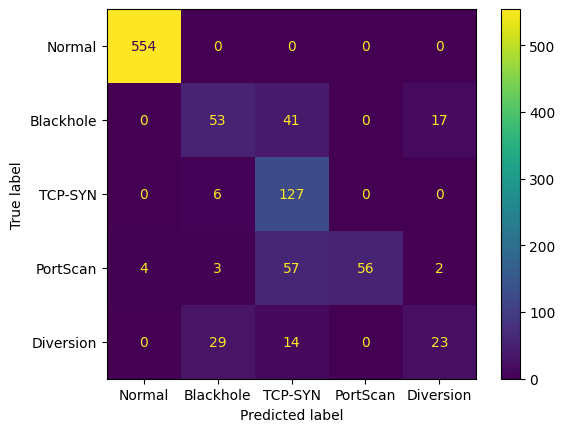

In [70]:
displayConfusMatrix(tarTest, NBTestResult)

## Show which is best model

In [71]:
print(f"Accuracy of the KNN Model : {KNNAccuracyScore:.2f}")
print(f"Accuracy of the Naive Bias Gaussian Model : {NBAccuracyScore:.2f}")

if (KNNAccuracyScore > NBAccuracyScore):
    selectedModel = knn
    accSelectedModel = str(KNNAccuracyScore)
    print("KNN Model is best suitable model.")
elif (KNNAccuracyScore < NBAccuracyScore):
    selectedModel = naiveBayes
    accSelectedModel = str(NBAccuracyScore)
    print("Naive Bias is the best suitable model.")
else :
    selectedModel = naiveBayes
    accSelectedModel = str(NBAccuracyScore)
    print("Both KNN & Naive Bias yeild same result.")

Accuracy of the KNN Model : 0.76
Accuracy of the Naive Bias Gaussian Model : 0.82
Naive Bias is the best suitable model.


## Save the model

In [72]:
modelFileName =f"../models/best_model_{accSelectedModel}_percentage"
joblib.dump(selectedModel, modelFileName)

['../models/best_model_0.8245436105476673_percentage']

## Continued 
##  _2_predict.ipynb